<a href="https://colab.research.google.com/github/bailey-hall/CS-472-572-Final-Project/blob/main/CS_472_572_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Load the data

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Data file paths
train_data_path = '/content/train.csv'
test_data_path = '/content/test.csv'

# Put data into pandas data frames
train_df = pd.read_csv(train_data_path)
test_df = pd.read_csv(test_data_path)

# Separate features from labels, as we are concerned with unsupervised clustering
X_train = train_df.drop(['subject', 'Activity'], axis=1)
y_train = train_df['Activity']

X_test = test_df.drop(['subject', 'Activity'], axis=1)
y_test = test_df['Activity']

# Combine test and training data, since we don't need the split for unsupervised clustering
X_combined = pd.concat([X_train, X_test], ignore_index=True)
y_combined = pd.concat([y_train, y_test], ignore_index=True)

# Scale features (all features have a mean of 0 and a standard deviation of 1)
# This is because K-means measures distances between feature values
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

print(X_combined_scaled)
print("")
print(X_combined_scaled.shape)

[[ 2.10533854e-01 -6.87026385e-02 -4.52194533e-01 ... -6.74432366e-01
   3.82007658e-01 -1.61505480e-02]
 [ 6.02084832e-02  3.59023537e-02 -2.75221885e-01 ... -6.81359801e-01
   3.83147865e-01 -1.20627169e-04]
 [ 7.84597052e-02 -4.64269585e-02 -8.55480582e-02 ... -6.89470939e-01
   3.84288531e-01  1.92144041e-02]
 ...
 [ 1.11821625e+00  1.28805864e+00 -1.29414692e-01 ... -3.10750224e-01
   6.91509049e-01  8.75719123e-01]
 [-5.43492722e-01  9.75327452e-01  2.34319837e-01 ... -3.19283719e-01
   6.59762215e-01  8.99444350e-01]
 [-1.78515253e+00 -1.86663622e-02 -5.29759691e-01 ... -3.19991245e-01
   6.56994458e-01  9.01454465e-01]]

(10299, 561)


In [4]:
# Basic K-means implementation

from sklearn.cluster import KMeans

# Apply K-means to the training data
# We know there are 6 activities, so we set n_clusters=6
kmeans = KMeans(n_clusters=6, init='random', random_state=42)
basic_clusters = kmeans.fit_predict(X_combined_scaled)

# Create a new dataframe to compare learned clusters and actual labels
basic_comparison_df = pd.DataFrame({'Cluster': basic_clusters, 'Actual_Activity': y_combined})

# Create a confusion matrix showing how many times each activity appeared in each cluster
basic_cluster_dist = pd.crosstab(basic_comparison_df['Cluster'], basic_comparison_df['Actual_Activity'])

In [5]:
# PCA + K-means implementation

from sklearn.decomposition import PCA

# Apply PCA to scaled training data in order to reduce the 500+ components to 50
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_combined_scaled)

# Apply K-means to the PCA-processed data
kmeans_pca = KMeans(n_clusters=6, init='random', random_state=42)
pca_clusters = kmeans_pca.fit_predict(X_pca)

# See how much variance in the data is explained by the 50 components
print(f"Percent of total variance explained by 50 components: {sum(pca.explained_variance_ratio_):.2%}\n")

# Create a new dataframe to compare learned clusters and actual labels
pca_comparison_df = pd.DataFrame({'Cluster': pca_clusters, 'Actual_Activity': y_combined})

# Create a confusion matrix showing how many times each activity appeared in each cluster
pca_cluster_dist = pd.crosstab(pca_comparison_df['Cluster'], pca_comparison_df['Actual_Activity'])


Percent of total variance explained by 50 components: 87.10%



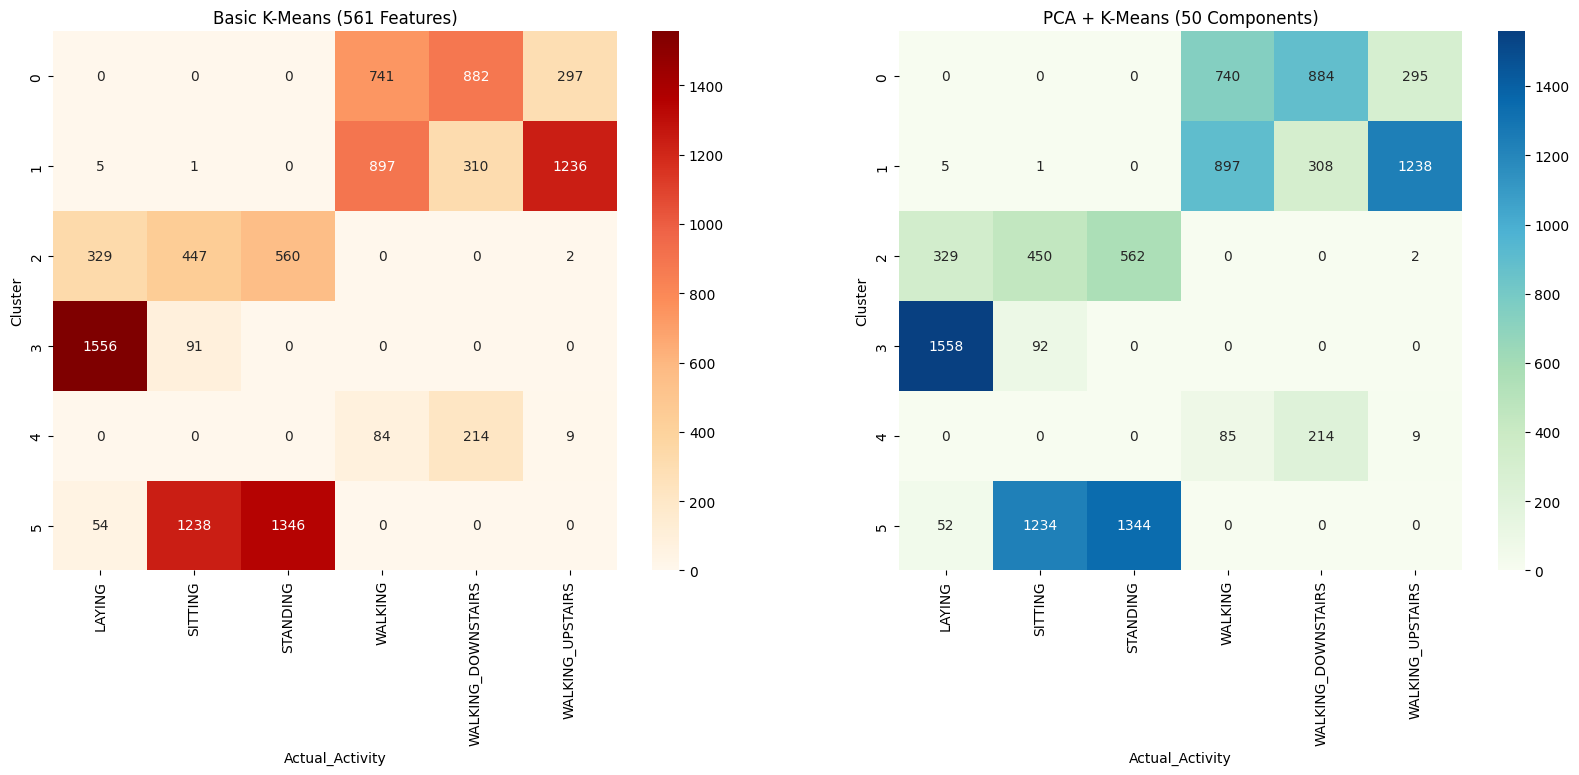


Basic K-Means Silhouette Score: 0.1099, PCA+K-Means Silhouette Score: 0.1524
Basic K-Means ARI Score: 0.4196, PCA+K-Means ARI Score: 0.4201


In [6]:
# Basic K-means and PCA+K-means Comparison

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Plot confusion matrices side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(basic_cluster_dist, annot=True, fmt='d', cmap='OrRd', ax=ax[0])
ax[0].set_title('Basic K-Means (561 Features)')
sns.heatmap(pca_cluster_dist, annot=True, fmt='d', cmap='GnBu', ax=ax[1])
ax[1].set_title('PCA + K-Means (50 Components)')
plt.show()

# Get Silhouette and Adjusted Rand Index (ARI) Scores
basic_sil_score = silhouette_score(X_combined_scaled, basic_clusters)
basic_ari_score = adjusted_rand_score(y_combined, basic_clusters)
pca_sil_score = silhouette_score(X_pca, pca_clusters)
pca_ari_score = adjusted_rand_score(y_combined, pca_clusters)

# Print scores (higher is better)
print(f"\nBasic K-Means Silhouette Score: {basic_sil_score:.4f}, PCA+K-Means Silhouette Score: {pca_sil_score:.4f}")
print(f"Basic K-Means ARI Score: {basic_ari_score:.4f}, PCA+K-Means ARI Score: {pca_ari_score:.4f}")

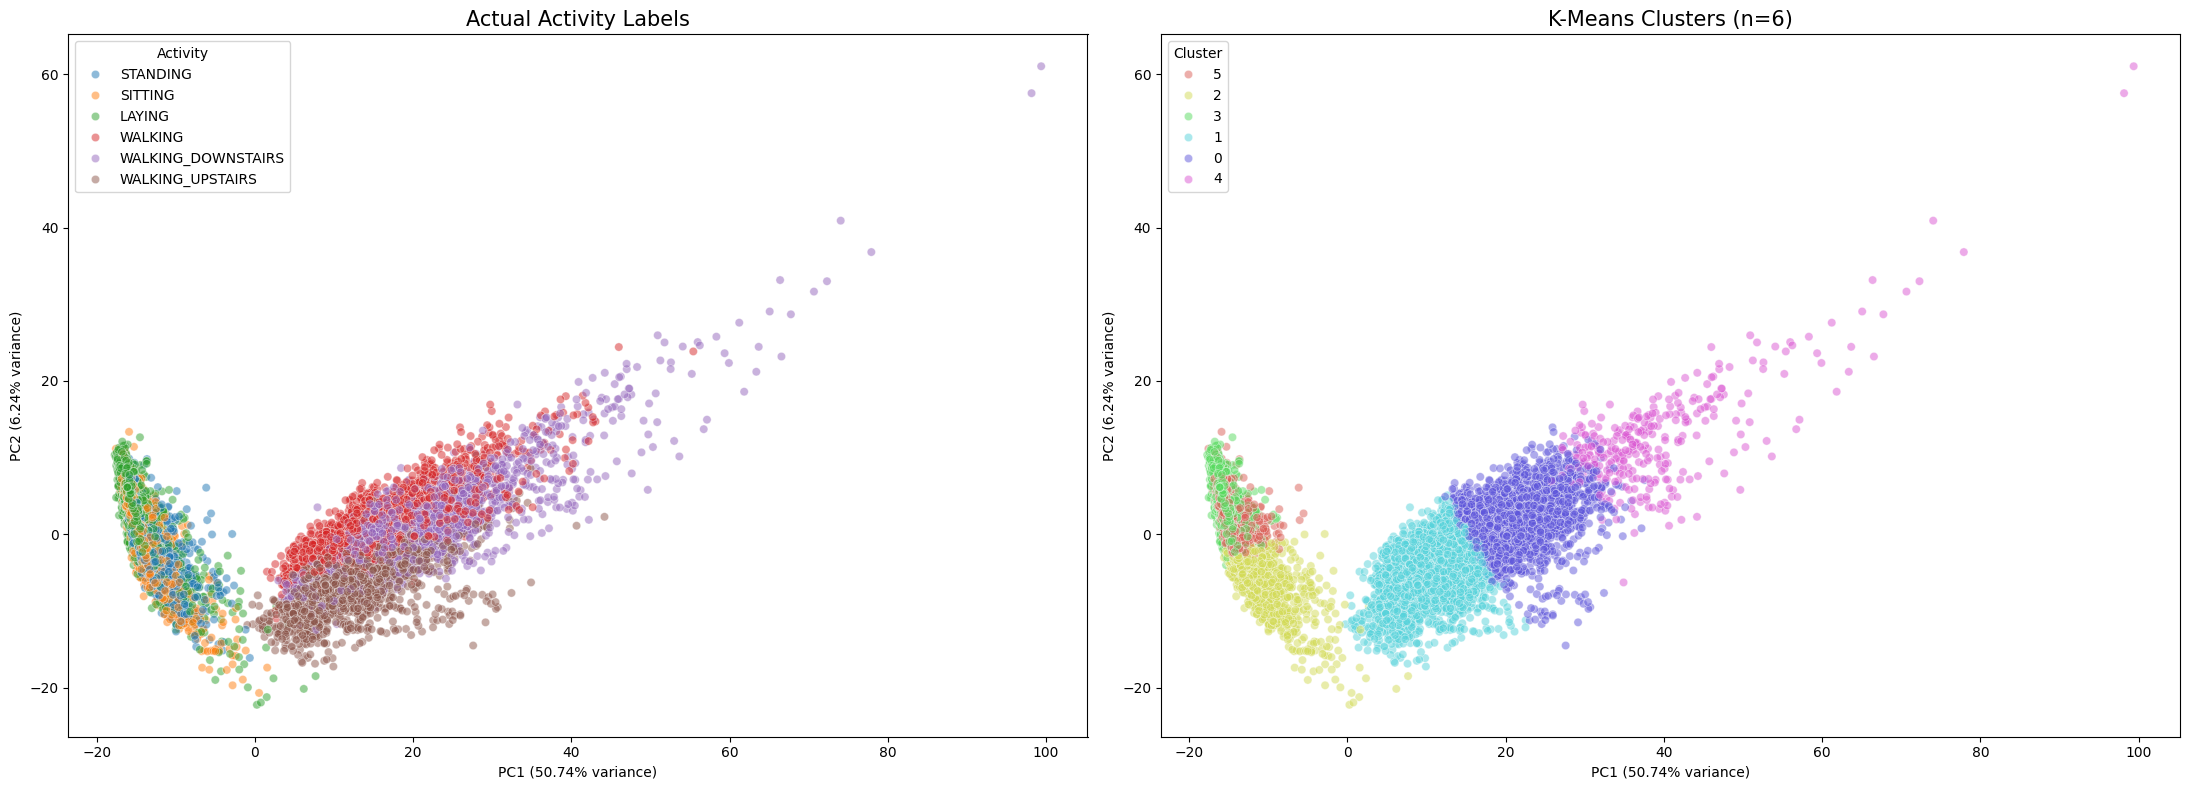

In [7]:
# Scatterplots with PC1 and PC2 as the axes to visualize clustering performance

# Create a dataframe for plotting, contains both actual labels and K-means cluster assignments
# X_pca[:, 0] is the first component, X_pca[:, 1] is the second component
plot_df = pd.DataFrame({'PC1': X_pca[:, 0],'PC2': X_pca[:, 1],'Cluster': pca_clusters.astype(str),'Activity': y_combined})

# Set up plot
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# Plot actual activity labels
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Activity', palette='tab10', alpha=0.5, ax=ax[0])
ax[0].set_title('Actual Activity Labels', fontsize=15)
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

# Plot K-means clusters
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='hls', alpha=0.5, ax=ax[1])
ax[1].set_title('K-Means Clusters (n=6)', fontsize=15)
ax[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

plt.tight_layout()
plt.show()

In [8]:
# Hierarchical Clustering implementation

from sklearn.cluster import AgglomerativeClustering

# Apply Hierarchical (Agglomerative) Clustering to the PCA-processed data
# Use all four types of linkage, and calculate silhouette and ARI scores for each

# Single Linkage
single_hc = AgglomerativeClustering(n_clusters=6, linkage='single')
single_hc_clusters = single_hc.fit_predict(X_pca)

single_hc_sil = silhouette_score(X_pca, single_hc_clusters)
single_hc_ari = adjusted_rand_score(y_combined, single_hc_clusters)

# Complete Linkage
complete_hc = AgglomerativeClustering(n_clusters=6, linkage='complete')
complete_hc_clusters = complete_hc.fit_predict(X_pca)

complete_hc_sil = silhouette_score(X_pca, complete_hc_clusters)
complete_hc_ari = adjusted_rand_score(y_combined, complete_hc_clusters)

# Average Linkage
average_hc = AgglomerativeClustering(n_clusters=6, linkage='average')
average_hc_clusters = average_hc.fit_predict(X_pca)

average_hc_sil = silhouette_score(X_pca, average_hc_clusters)
average_hc_ari = adjusted_rand_score(y_combined, average_hc_clusters)

# Ward Linkage
ward_hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
ward_hc_clusters = ward_hc.fit_predict(X_pca)

ward_hc_sil = silhouette_score(X_pca, ward_hc_clusters)
ward_hc_ari = adjusted_rand_score(y_combined, ward_hc_clusters)

# Print different linkage scores for comparison
print("Single Linkage:")
print(f"Silhouette Score: {single_hc_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {single_hc_ari:.4f}")
print("\nComplete Linkage:")
print(f"Silhouette Score: {complete_hc_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {complete_hc_ari:.4f}")
print("\nAverage Linkage:")
print(f"Silhouette Score: {average_hc_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {average_hc_ari:.4f}")
print("\nWard Linkage:")
print(f"Silhouette Score: {ward_hc_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ward_hc_ari:.4f}")

Single Linkage:
Silhouette Score: 0.6424
Adjusted Rand Index (ARI): 0.0001

Complete Linkage:
Silhouette Score: 0.2434
Adjusted Rand Index (ARI): 0.0794

Average Linkage:
Silhouette Score: 0.4076
Adjusted Rand Index (ARI): 0.0032

Ward Linkage:
Silhouette Score: 0.1294
Adjusted Rand Index (ARI): 0.4218


In [9]:
# Spectral Clustering implementation

from sklearn.cluster import SpectralClustering

# Apply Spectral Clustering to the PCA-processed data
# affinity='nearest_neighbors' for faster computing
# Try both 'kmeans' and 'discretize' for assign_labels, calculate silhouette and ARI scores for both

# assign_labels='kmeans'
kmeans_spec = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
kmeans_spec_clusters = kmeans_spec.fit_predict(X_pca)

kmeans_spec_sil = silhouette_score(X_pca, kmeans_spec_clusters)
kmeans_spec_ari = adjusted_rand_score(y_combined, kmeans_spec_clusters)

# assign_labels='discretize'
discretize_spec = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', assign_labels='discretize', random_state=42)
discretize_spec_clusters = discretize_spec.fit_predict(X_pca)

discretize_spec_sil = silhouette_score(X_pca, discretize_spec_clusters)
discretize_spec_ari = adjusted_rand_score(y_combined, discretize_spec_clusters)

# Print scores
print("assign_labels='kmeans':")
print(f"Silhouette Score: {kmeans_spec_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_spec_ari:.4f}")
print("\nassign_labels='discretize':")
print(f"Silhouette Score: {discretize_spec_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {discretize_spec_ari:.4f}")

assign_labels='kmeans':
Silhouette Score: 0.0942
Adjusted Rand Index (ARI): 0.4922

assign_labels='discretize':
Silhouette Score: 0.1096
Adjusted Rand Index (ARI): 0.4947


In [10]:
# DBSCAN implementation

from sklearn.cluster import DBSCAN

# Apply DBSCAN to the PCA-processed data
# After tuning, combination of eps=11 and min_samples=4 produces the highest ARI score
dbscan = DBSCAN(eps=11, min_samples=4)
dbscan_clusters = dbscan.fit_predict(X_pca)

# Identify Clusters and Noise
n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0) # exclude data labeled with -1 (noise)
n_noise = list(dbscan_clusters).count(-1) # could all data labeled with -1 (noise)
print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise} (out of {len(X_pca)} data points)")

# Calculate Silhouette and Adjusted Rand Index (ARI) Scores

# We filter both the features (X_pca) and the labels (dbscan_clusters) to exclude noise (data labeled -1)
db_sil = silhouette_score(X_pca[dbscan_clusters != -1], dbscan_clusters[dbscan_clusters != -1])
# The ARI formula naturally treats -1 as just another cluster label
db_ari = adjusted_rand_score(y_combined, dbscan_clusters)

# Print scores
print(f"Silhouette Score (excluding noise): {db_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {db_ari:.4f}")

Estimated number of clusters: 34
Estimated number of noise points: 1791 (out of 10299 data points)
Silhouette Score (excluding noise): 0.1794
Adjusted Rand Index (ARI): 0.3223


In [11]:
# Gaussian Mixture Model (GMM) implementation

from sklearn.mixture import GaussianMixture

# Apply GMM to the PCA-processed data
# Use all four types of covariance, and calculate silhouette and ARI scores for each

# Spherical covariance
spherical_gmm = GaussianMixture(n_components=6, covariance_type='spherical', random_state=42)
spherical_gmm.fit(X_pca)
spherical_gmm_clusters = spherical_gmm.predict(X_pca)

spherical_gmm_sil = silhouette_score(X_pca, spherical_gmm_clusters)
spherical_gmm_ari = adjusted_rand_score(y_combined, spherical_gmm_clusters)

# Diagonal covariance
diag_gmm = GaussianMixture(n_components=6, covariance_type='diag', random_state=42)
diag_gmm.fit(X_pca)
diag_gmm_clusters = diag_gmm.predict(X_pca)

diag_gmm_sil = silhouette_score(X_pca, diag_gmm_clusters)
diag_gmm_ari = adjusted_rand_score(y_combined, diag_gmm_clusters)

# Tied covariance
tied_gmm = GaussianMixture(n_components=6, covariance_type='tied', random_state=42)
tied_gmm.fit(X_pca)
tied_gmm_clusters = tied_gmm.predict(X_pca)

tied_gmm_sil = silhouette_score(X_pca, tied_gmm_clusters)
tied_gmm_ari = adjusted_rand_score(y_combined, tied_gmm_clusters)

# Full covariance
full_gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=42)
full_gmm.fit(X_pca)
full_gmm_clusters = full_gmm.predict(X_pca)

full_gmm_sil = silhouette_score(X_pca, full_gmm_clusters)
full_gmm_ari = adjusted_rand_score(y_combined, full_gmm_clusters)

# Print scores
print("Spherical Covariance:")
print(f"Silhouette Score: {spherical_gmm_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {spherical_gmm_ari:.4f}")
print("\nDiagonal Covariance:")
print(f"Silhouette Score: {diag_gmm_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {diag_gmm_ari:.4f}")
print("\nTied Covariance:")
print(f"Silhouette Score: {tied_gmm_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {tied_gmm_ari:.4f}")
print("\nFull Covariance:")
print(f"Silhouette Score: {full_gmm_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {full_gmm_ari:.4f}")

Spherical Covariance:
Silhouette Score: 0.1087
Adjusted Rand Index (ARI): 0.2765

Diagonal Covariance:
Silhouette Score: 0.0669
Adjusted Rand Index (ARI): 0.3015

Tied Covariance:
Silhouette Score: 0.1348
Adjusted Rand Index (ARI): 0.4278

Full Covariance:
Silhouette Score: 0.1455
Adjusted Rand Index (ARI): 0.3181


In [12]:
# Display ARI and Silhouette scores for each model

# Collecting results
comparison_data = [
    {'Model': 'K-Means', 'ARI': pca_ari_score, 'Silhouette': pca_sil_score},
    {'Model': 'Hierarchical (Ward)', 'ARI': ward_hc_ari, 'Silhouette': ward_hc_sil},
    {'Model': 'Spectral (Discretize)', 'ARI': discretize_spec_ari, 'Silhouette': discretize_spec_sil},
    {'Model': 'DBSCAN', 'ARI': db_ari, 'Silhouette': db_sil},
    {'Model': 'GMM (Tied)', 'ARI': tied_gmm_ari, 'Silhouette': tied_gmm_sil}
    ]

comparison_df = pd.DataFrame(comparison_data)
print("Clustering Performance Comparison:")
print(comparison_df.sort_values(by='ARI', ascending=False).to_string(index=False))

Clustering Performance Comparison:
                Model      ARI  Silhouette
Spectral (Discretize) 0.494739    0.109598
           GMM (Tied) 0.427750    0.134806
  Hierarchical (Ward) 0.421752    0.129356
              K-Means 0.420084    0.152449
               DBSCAN 0.322263    0.179438


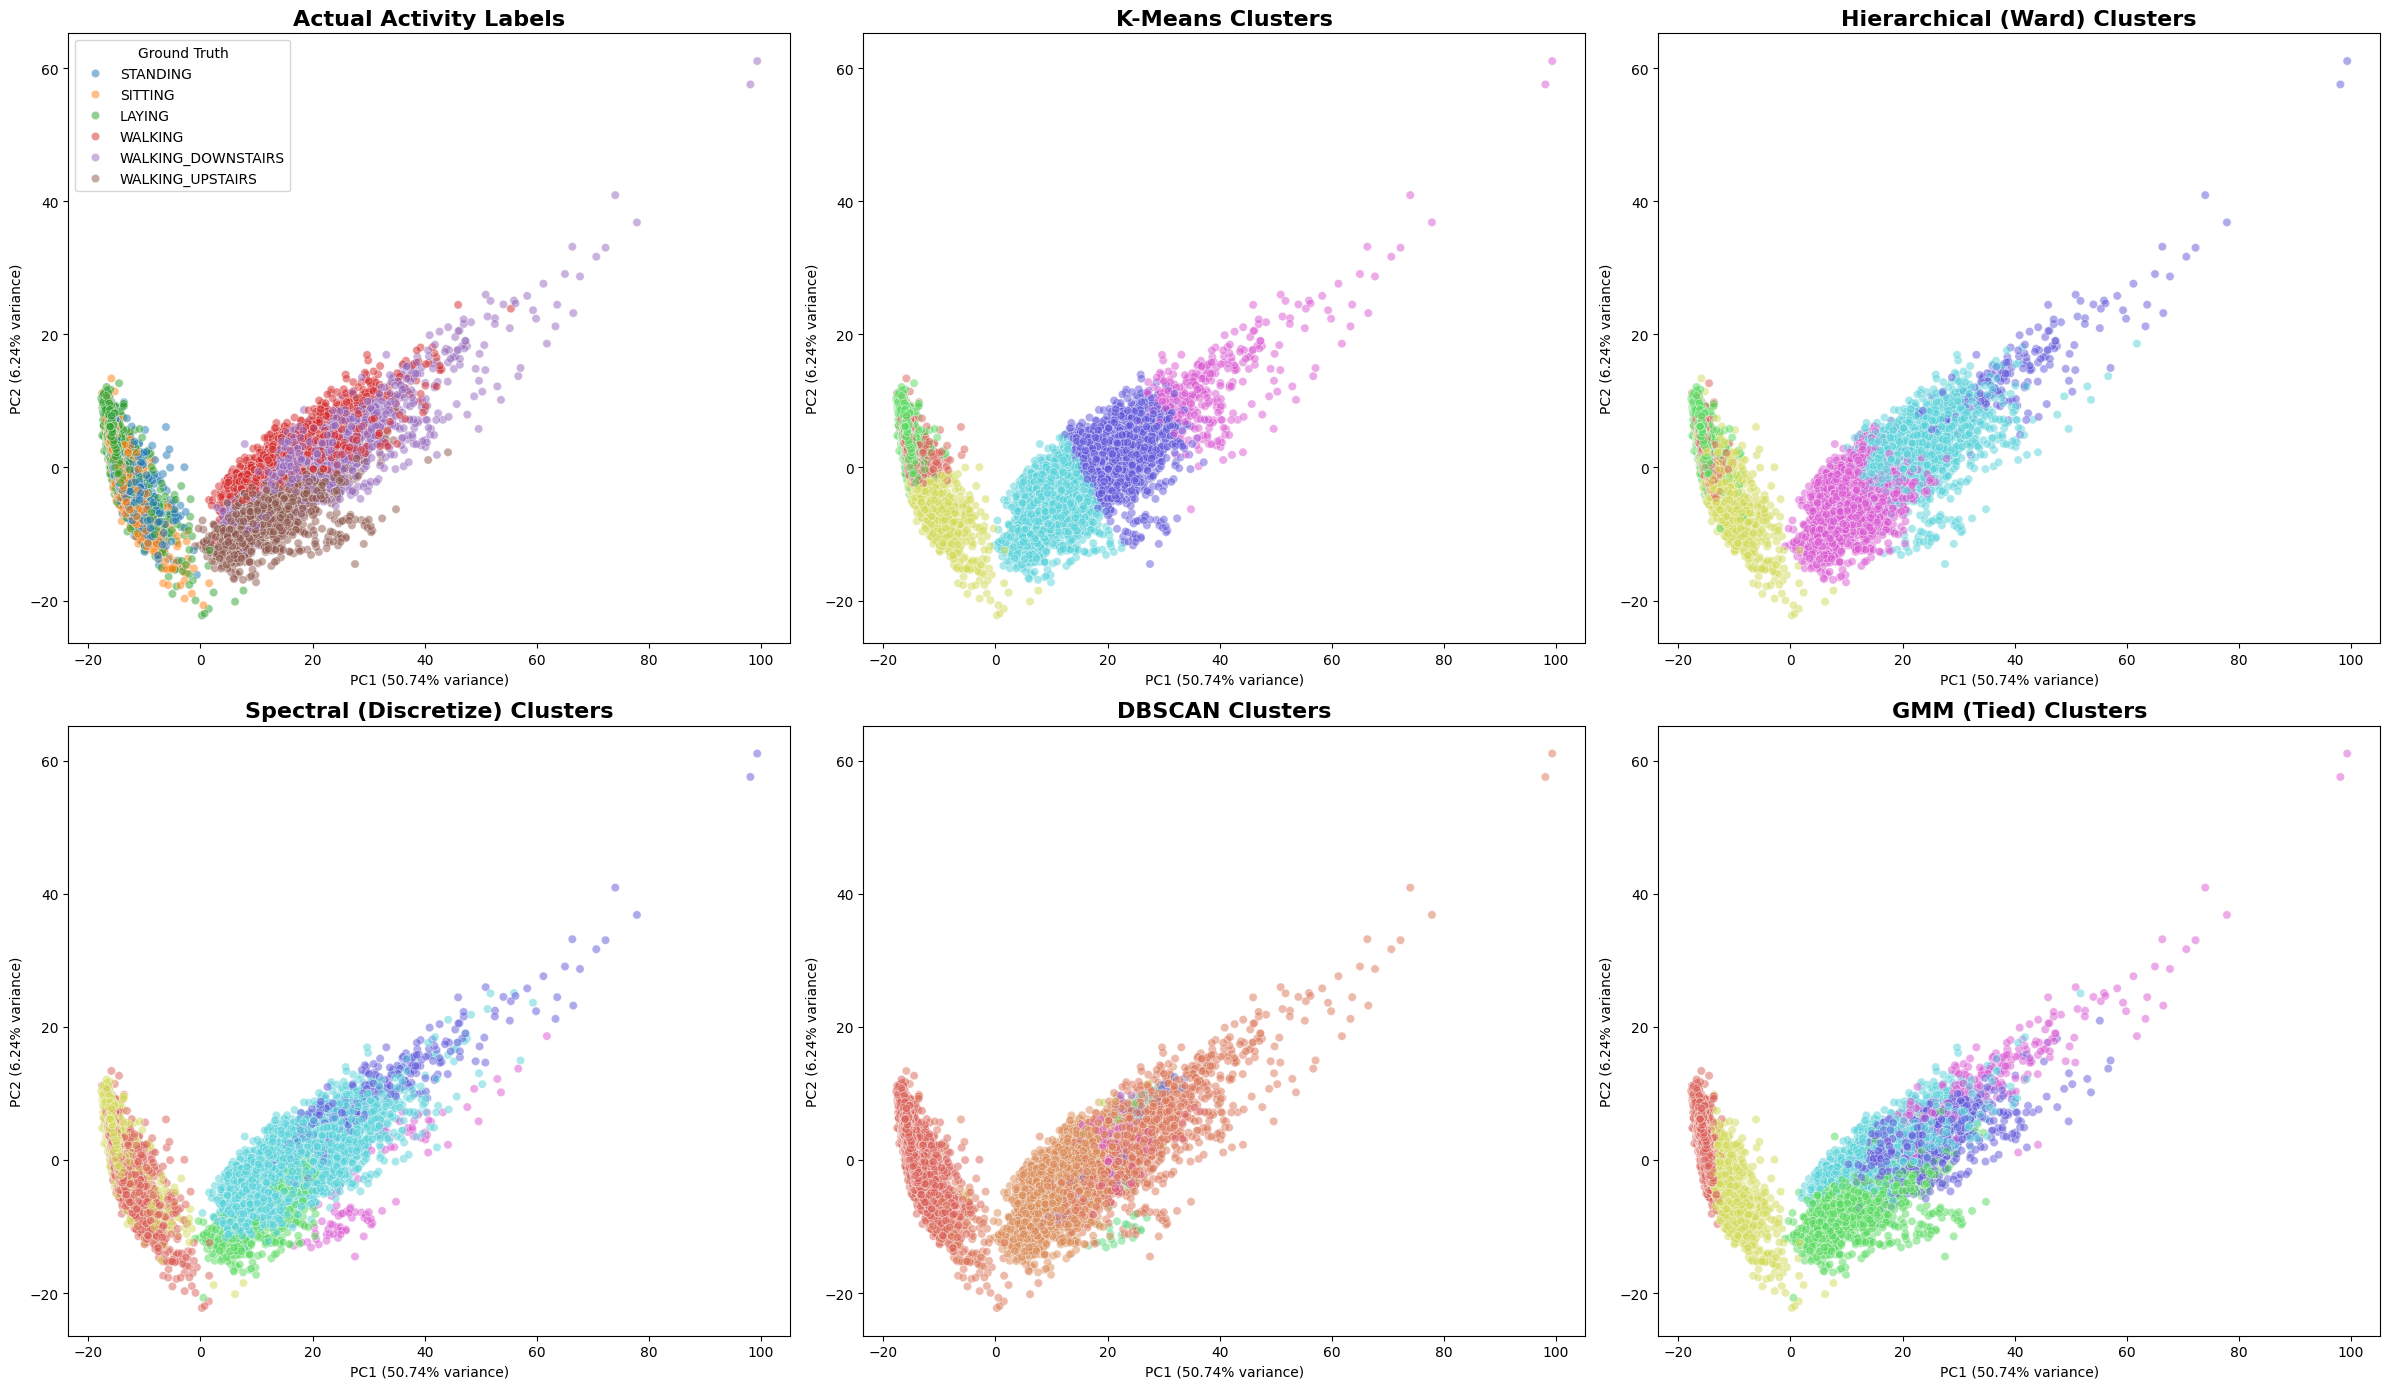

In [13]:
# Scatterplots with PC1 and PC2 as the axes to visualize clustering performance of all models

# Create a dataframe for plotting
# Convert cluster labels to strings, so they are treated as categorical data
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Ground Truth': y_combined,
    'K-Means': pca_clusters.astype(str),
    'Hierarchical': ward_hc_clusters.astype(str),
    'Spectral': discretize_spec_clusters.astype(str),
    'DBSCAN': dbscan_clusters.astype(str),
    'GMM': tied_gmm_clusters.astype(str)
})

# Columns names and corresponding plot titles
grid_cols = ['Ground Truth', 'K-Means', 'Hierarchical', 'Spectral', 'DBSCAN', 'GMM']
titles = ['Actual Activity Labels', 'K-Means Clusters', 'Hierarchical (Ward) Clusters',
          'Spectral (Discretize) Clusters', 'DBSCAN Clusters', 'GMM (Tied) Clusters']

# Set up grid plot
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# Axis labels (same for all plots)
pc1_label = f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)'
pc2_label = f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)'

# Generate each plot
for i, col in enumerate(grid_cols):
    palette = 'tab10' if col == 'Ground Truth' else 'hls'
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue=col, palette=palette, alpha=0.5, ax=axes[i], legend=(col == 'Ground Truth'))

    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_xlabel(pc1_label)
    axes[i].set_ylabel(pc2_label)

plt.tight_layout()
plt.show()

In [14]:
# Autoencoder Extension
# Code adapted from:
  # https://medium.com/analytics-vidhya/autoencoders-with-tensorflow-2f0a7315d161

import tensorflow as tf
from keras import layers, models

# --- Autoencoder dimension parameters: ---
input_dim = X_combined_scaled.shape[1] # 561 features
latent_dim = 50  # Latent space dimension to match the 50 PCA components
hidden_dim = 150 # Hidden layer dimension

# --- Encoder: ---
encoder_input = layers.Input(shape=(input_dim,))
encoder_hidden = layers.Dense(hidden_dim, activation='relu')(encoder_input)
encoder_output = layers.Dense(latent_dim, activation='relu')(encoder_hidden)
encoder = models.Model(encoder_input, encoder_output)

# --- Decoder: ---
decoder_input = layers.Dense(latent_dim, activation='relu')(encoder_output)
decoder_hidden = layers.Dense(hidden_dim, activation='relu')(decoder_input)
decoder_output = layers.Dense(input_dim)(decoder_hidden)
decoder = models.Model(decoder_input, decoder_output)

# --- Autoencoder: ---
autoencoder = models.Model(encoder_input, decoder_output)
autoencoder.compile(optimizer='adam', loss='mse') # compile and train

# --- Train the model to reconstruct the input: ---
autoencoder.fit(X_combined_scaled, X_combined_scaled, epochs=50, batch_size=64, shuffle=True, verbose=0)

# --- Get learned latent features from the now-trained encoder: ---
X_autoencode = encoder.predict(X_combined_scaled)

# -- Use K-means on latent features: ---
kmeans_ae = KMeans(n_clusters=6, init='random', random_state=42)
kmeans_ae_clusters = kmeans_ae.fit_predict(X_autoencode)

# --- Use Spectral (discretize) on latent features, since it performed the best on PCA components: ---
spec_ae = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', assign_labels='discretize', random_state=42)
spec_ae_clusters = spec_ae.fit_predict(X_autoencode)

322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


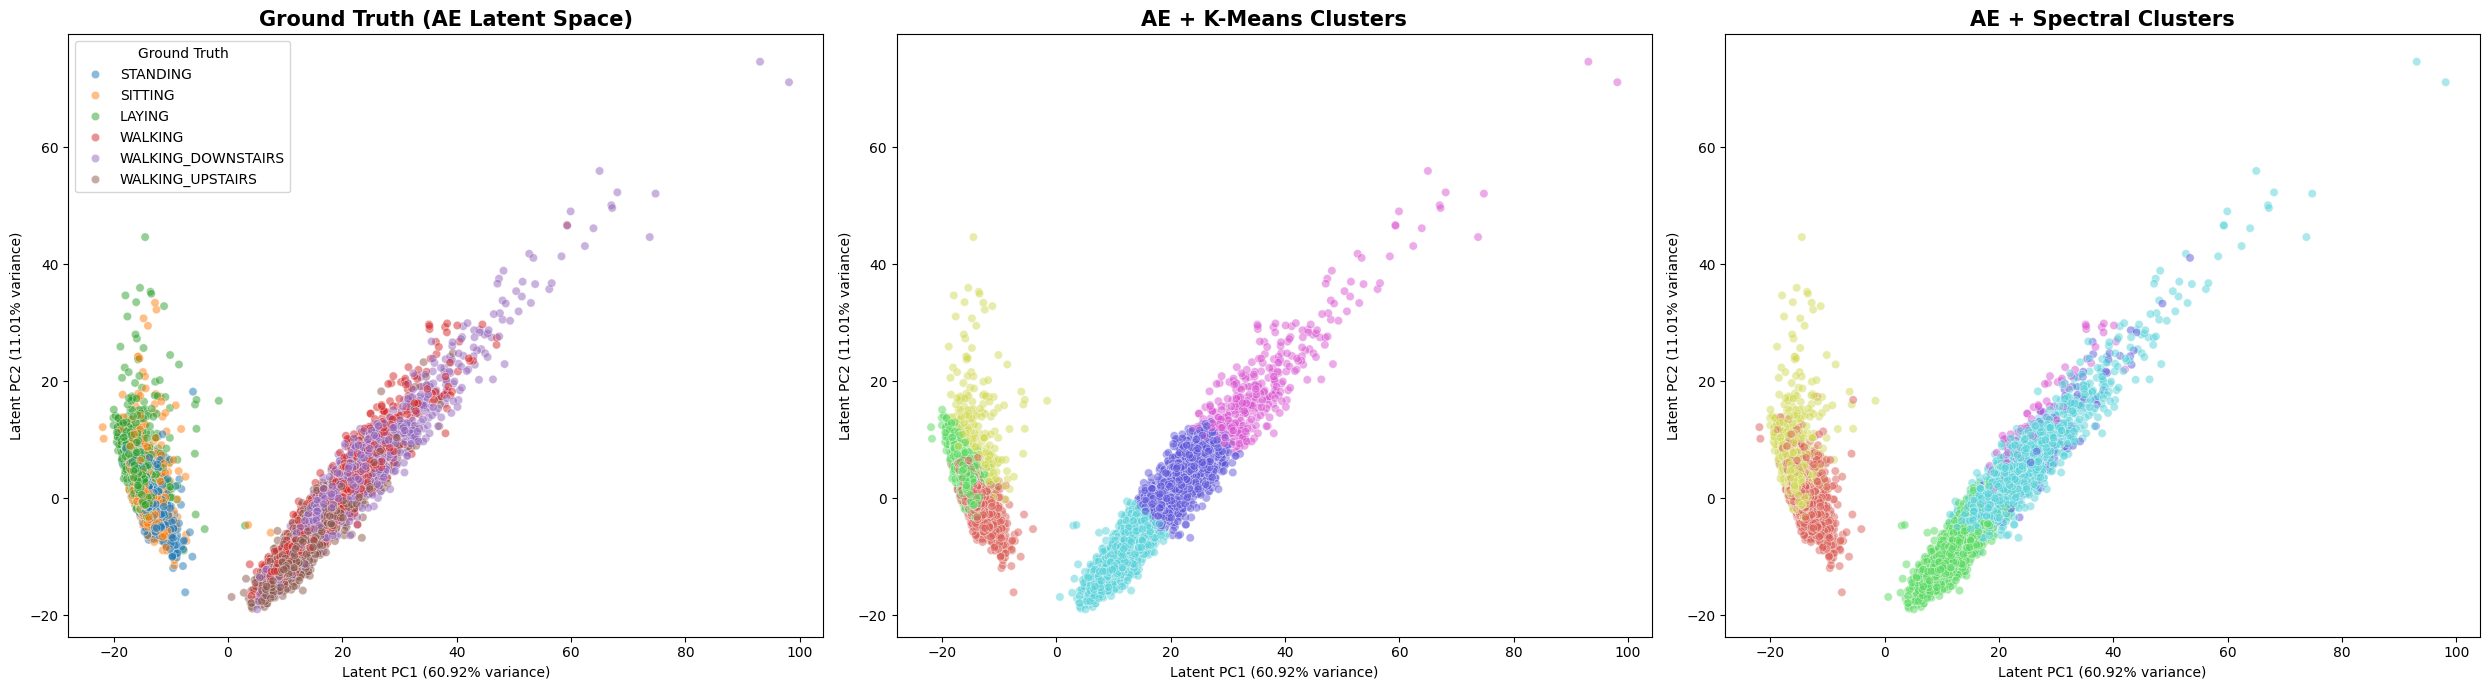


Autoencoder + K-Means:
Silhouette Score: 0.1744
Adjusted Rand Index (ARI): 0.4623

Autoencoder + Spectral (discretize):
Silhouette Score: 0.1702
Adjusted Rand Index (ARI): 0.5364


In [15]:
# Autoencoder extension visualization and metrics

# Reduce the 50 latent features to 2D for visualization using PCA
pca_ae = PCA(n_components=2)
X_ae_2d = pca_ae.fit_transform(X_autoencode)

# Create a combined dataframe for plotting
plot_ae_df = pd.DataFrame({'AE_PC1': X_ae_2d[:, 0],
                           'AE_PC2': X_ae_2d[:, 1],
                           'Ground Truth': y_combined,
                           'AE_KMeans': kmeans_ae_clusters.astype(str),
                           'AE_Spectral': spec_ae_clusters.astype(str)})

# Set up the plot grid
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# Plot titles and columns
ae_cols = ['Ground Truth', 'AE_KMeans', 'AE_Spectral']
ae_titles = ['Ground Truth (AE Latent Space)', 'AE + K-Means Clusters', 'AE + Spectral Clusters']

# Axis labels
ae_x_label = f'Latent PC1 ({pca_ae.explained_variance_ratio_[0]:.2%} variance)'
ae_y_label = f'Latent PC2 ({pca_ae.explained_variance_ratio_[1]:.2%} variance)'

for i, col in enumerate(ae_cols):
    # 'tab10' for ground truth/labels and 'hls' for learned clusters
    palette = 'tab10' if col == 'Ground Truth' else 'hls'
    sns.scatterplot(data=plot_ae_df, x='AE_PC1', y='AE_PC2', hue=col,
                    palette=palette, alpha=0.5, ax=axes[i],
                    legend=(col == 'Ground Truth') # show legend for ground truth
                    )
    axes[i].set_title(ae_titles[i], fontsize=15, fontweight='bold')
    axes[i].set_xlabel(ae_x_label)
    axes[i].set_ylabel(ae_y_label)

plt.tight_layout()
plt.show()

# Calculate and print scores to evaluate clustering performance
kmeans_ae_sil = silhouette_score(X_autoencode, kmeans_ae_clusters)
kmeans_ae_ari = adjusted_rand_score(y_combined, kmeans_ae_clusters)
spec_ae_sil = silhouette_score(X_autoencode, spec_ae_clusters)
spec_ae_ari = adjusted_rand_score(y_combined, spec_ae_clusters)
print(f"\nAutoencoder + K-Means:")
print(f"Silhouette Score: {kmeans_ae_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ae_ari:.4f}")
print(f"\nAutoencoder + Spectral (discretize):")
print(f"Silhouette Score: {spec_ae_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {spec_ae_ari:.4f}")

In [16]:
# Convolutional Variational Autoencoder (CVAE) Extension
# Code adapted from:
  # https://www.geeksforgeeks.org/deep-learning/convolutional-variational-autoencoder-in-tensorflow/
  # https://www.tensorflow.org/tutorials/generative/cvae

from keras import backend, ops, random

# --- Reshape data for CVAE and parameters: ---
X_reshaped = X_combined_scaled.reshape(-1, 561, 1)
input_shape = (561,1) # 561 features
latent_dim = 50  # Latent space dimension to match the 50 PCA components

# --- Encoder Layer: ---
encoder_input = layers.Input(shape=input_shape)
# convolutional layer 1
conv_1 = layers.Conv1D(filters=32,kernel_size=3,padding='same',activation='relu')(encoder_input)
# reduce size (561 -> 280)
pool_1 = layers.MaxPooling1D(pool_size=2)(conv_1)
# convolutional layer 2
conv_2 = layers.Conv1D(filters=64,kernel_size=3,padding='same',activation='relu')(pool_1)
# reduce size (280 -> 140)
pool_2 = layers.MaxPooling1D(pool_size=2)(conv_2)
# flatten the data
flatten_1 = layers.Flatten()(pool_2)
# dense layers
encoder_output = layers.Dense(128, activation='relu')(flatten_1)
z_mu = layers.Dense(latent_dim, name='z_mu')(encoder_output)
z_log_sigma = layers.Dense(latent_dim, name='z_log_sigma')(encoder_output)

# --- Latent Layer: ---
def sampling(args):
  z_mu, z_log_sigma = args
  batch = ops.shape(z_mu)[0]
  dim = ops.shape(z_mu)[1]
  epsilon = random.normal(shape=(batch, dim),seed=42)
  return z_mu + ops.exp(0.5 * z_log_sigma) * epsilon
z = layers.Lambda(sampling, output_shape=(latent_dim,))([z_mu, z_log_sigma])

# --- Decoder Layer: ---
decoder_input = layers.Input(shape=(latent_dim,))
# dense layer
decoder_dense = layers.Dense(140*64, activation='relu')(decoder_input)
# reshape layer
reshape = layers.Reshape((140,64))(decoder_dense)
# deconvolutional layer 1
conv_3 = layers.Conv1DTranspose(filters=64,kernel_size=3,strides=2,padding='same',activation='relu')(reshape)
# deconvolutional layer 2
conv_4 = layers.Conv1DTranspose(filters=32,kernel_size=3,strides=2,padding='same',activation='relu')(conv_3)
# flatten to match original number of features
flatten_2 = layers.Flatten()(conv_4)
decoder_output = layers.Dense(561, activation='linear')(flatten_2)

# --- Models: ---
encoder = models.Model(encoder_input, [z_mu, z_log_sigma, z], name='encoder')
decoder = models.Model(decoder_input, decoder_output, name='decoder')
class CVAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # pass data through encoder
            z_mu, z_log_sigma, z = self.encoder(data)
            # pass latent data through decoder
            reconstruction = self.decoder(z)
            # flatten data for MSE comparison
            data_flat = ops.reshape(data, (-1, 561))
            # calculate losses (reconstruction and KL)
            reconstruction_loss = ops.mean(ops.square(data_flat - reconstruction))
            kl_loss = -0.5 * ops.mean(1 + z_log_sigma - ops.square(z_mu) - ops.exp(z_log_sigma))
            # small beta to reduce weight of kl loss on total loss
            beta = 0.0001
            # combine losses
            total_loss = reconstruction_loss + (beta * kl_loss)
        # backpropagation with gradients
        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        return {"loss": total_loss, "recon_loss": reconstruction_loss, "kl_loss": kl_loss}

# --- Compile and Train: ---
cvae = CVAE(encoder, decoder)
cvae.compile(optimizer='adam')
cvae.fit(X_reshaped, epochs=50, batch_size=64, verbose=0)

# --- Get learned latent features ---
X_cae, _, _ = cvae.encoder.predict(X_reshaped)

# -- Use K-means on latent features: ---
kmeans_cvae = KMeans(n_clusters=6, init='random', random_state=42)
kmeans_cvae_clusters = kmeans_cvae.fit_predict(X_cae)

# --- Use Spectral (discretize) on latent features, since it performed the best on PCA components: ---
spec_cvae = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', assign_labels='discretize', random_state=42)
spec_cvae_clusters = spec_cvae.fit_predict(X_cae)

322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


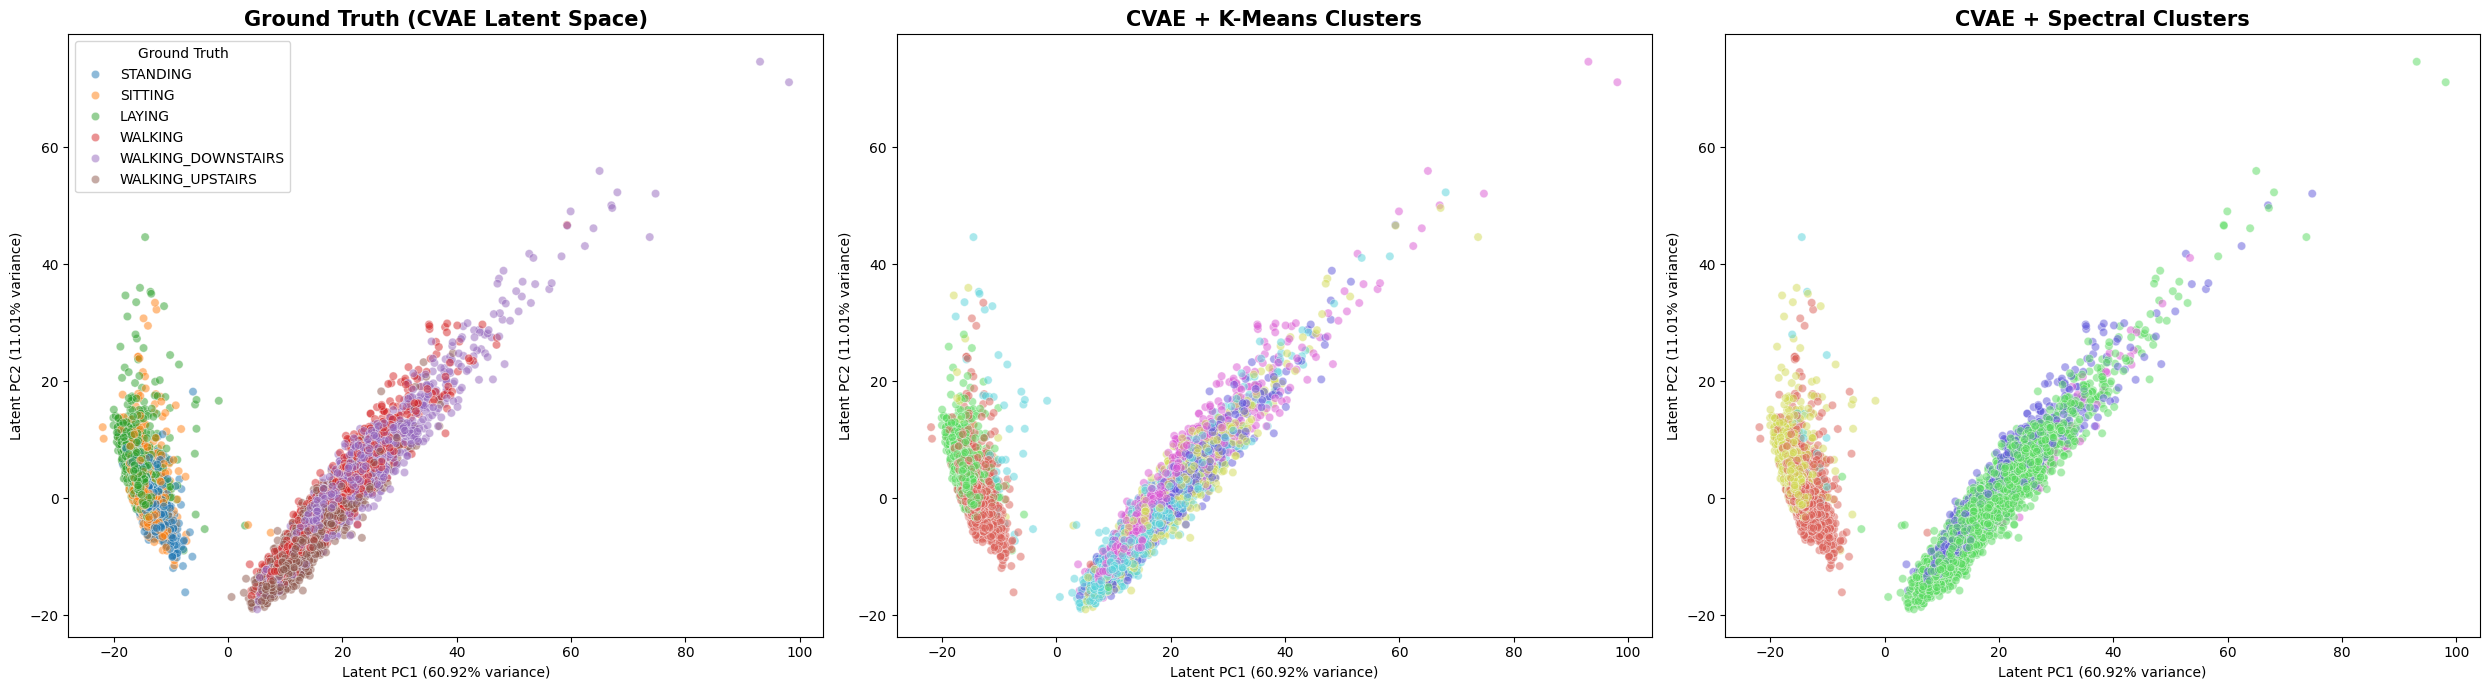


Convolutional Variational Autoencoder + K-Means:
Silhouette Score: 0.0750
Adjusted Rand Index (ARI): 0.6050

Convolutional Variational Autoencoder + Spectral (discretize):
Silhouette Score: 0.0595
Adjusted Rand Index (ARI): 0.5029


In [17]:
# Convolutional Variational Autoencoder extension visualization and metrics

# Reduce the 50 latent features to 2D for visualization using PCA
pca_cvae = PCA(n_components=2)
X_cvae_2d = pca_cvae.fit_transform(X_autoencode)

# Create a combined dataframe for plotting
plot_cvae_df = pd.DataFrame({'CVAE_PC1': X_cvae_2d[:, 0],
                           'CVAE_PC2': X_cvae_2d[:, 1],
                           'Ground Truth': y_combined,
                           'CVAE_KMeans': kmeans_cvae_clusters.astype(str),
                           'CVAE_Spectral': spec_cvae_clusters.astype(str)})

# Set up the plot grid
fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# Plot titles and columns
cvae_cols = ['Ground Truth', 'CVAE_KMeans', 'CVAE_Spectral']
cvae_titles = ['Ground Truth (CVAE Latent Space)', 'CVAE + K-Means Clusters', 'CVAE + Spectral Clusters']

# Axis labels
cvae_x_label = f'Latent PC1 ({pca_cvae.explained_variance_ratio_[0]:.2%} variance)'
cvae_y_label = f'Latent PC2 ({pca_cvae.explained_variance_ratio_[1]:.2%} variance)'

for i, col in enumerate(cvae_cols):
    # 'tab10' for ground truth/labels and 'hls' for learned clusters
    palette = 'tab10' if col == 'Ground Truth' else 'hls'
    sns.scatterplot(data=plot_cvae_df, x='CVAE_PC1', y='CVAE_PC2', hue=col,
                    palette=palette, alpha=0.5, ax=axes[i],
                    legend=(col == 'Ground Truth') # show legend for ground truth
                    )
    axes[i].set_title(cvae_titles[i], fontsize=15, fontweight='bold')
    axes[i].set_xlabel(cvae_x_label)
    axes[i].set_ylabel(cvae_y_label)

plt.tight_layout()
plt.show()

# Calculate and print scores to evaluate clustering performance
kmeans_cvae_sil = silhouette_score(X_cae, kmeans_cvae_clusters)
kmeans_cvae_ari = adjusted_rand_score(y_combined, kmeans_cvae_clusters)
spec_cvae_sil = silhouette_score(X_cae, spec_cvae_clusters)
spec_cvae_ari = adjusted_rand_score(y_combined, spec_cvae_clusters)
print(f"\nConvolutional Variational Autoencoder + K-Means:")
print(f"Silhouette Score: {kmeans_cvae_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_cvae_ari:.4f}")
print(f"\nConvolutional Variational Autoencoder + Spectral (discretize):")
print(f"Silhouette Score: {spec_cvae_sil:.4f}")
print(f"Adjusted Rand Index (ARI): {spec_cvae_ari:.4f}")